## import all dependencies for your project

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# step1 :loading the dataset

In [2]:
df=pd.read_excel('pima-data.xlsx')
df

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,diabetes_orig,skin,has_diabetes,diabetes
0,6,148,72,35,0,33.6,0.627,50,1,1.3790,True,True
1,1,85,66,29,0,26.6,0.351,31,0,1.1426,False,False
2,8,183,64,0,0,23.3,0.672,32,1,0.0000,True,True
3,1,89,66,23,94,28.1,0.167,21,0,0.9062,False,False
4,0,137,40,35,168,43.1,2.288,33,1,1.3790,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,1.8912,False,False
764,2,122,70,27,0,36.8,0.340,27,0,1.0638,False,False
765,5,121,72,23,112,26.2,0.245,30,0,0.9062,False,False
766,1,126,60,0,0,30.1,0.349,47,1,0.0000,True,True


In [3]:
df.shape # return type is tuple for shape

(768, 12)

In [4]:
df.info

<bound method DataFrame.info of      num_preg  glucose_conc  diastolic_bp  thickness  insulin   bmi  \
0           6           148            72         35        0  33.6   
1           1            85            66         29        0  26.6   
2           8           183            64          0        0  23.3   
3           1            89            66         23       94  28.1   
4           0           137            40         35      168  43.1   
..        ...           ...           ...        ...      ...   ...   
763        10           101            76         48      180  32.9   
764         2           122            70         27        0  36.8   
765         5           121            72         23      112  26.2   
766         1           126            60          0        0  30.1   
767         1            93            70         31        0  30.4   

     diab_pred  age  diabetes_orig    skin  has_diabetes  diabetes  
0        0.627   50              1  1.3790    

In [5]:
df.columns

Index(['num_preg', 'glucose_conc', 'diastolic_bp', 'thickness', 'insulin',
       'bmi', 'diab_pred', 'age', 'diabetes_orig', 'skin', 'has_diabetes',
       'diabetes'],
      dtype='str')

# step2:cleaning the dataset

# a.check the null values is present in dataset or not

In [6]:
#first check null values are present or not ,reomve the columnsif present perfrom below
#if datset is large then dropna
#if we have less no. of records fillna

In [7]:
df.isnull().sum()

num_preg         0
glucose_conc     0
diastolic_bp     0
thickness        0
insulin          0
bmi              0
diab_pred        0
age              0
diabetes_orig    0
skin             0
has_diabetes     0
diabetes         0
dtype: int64

# b.checking the corelation between the two columns

In [8]:
def check_corr(size):
    corr= df.corr()
    fig,ax=plt.subplots(figsize=(size,size))
    ax.matshow(corr,cmap='plasma') ## IN INTERNET SEARCH CMAP COLORS like rainbow
    plt.xticks(range(len(corr.columns)),corr.columns,rotation=45)
    # xticks(for numnbers,for columnnames , rotation means:inclinement of text in label
    plt.yticks(range(len(corr.columns)),corr.columns)
    plt.show

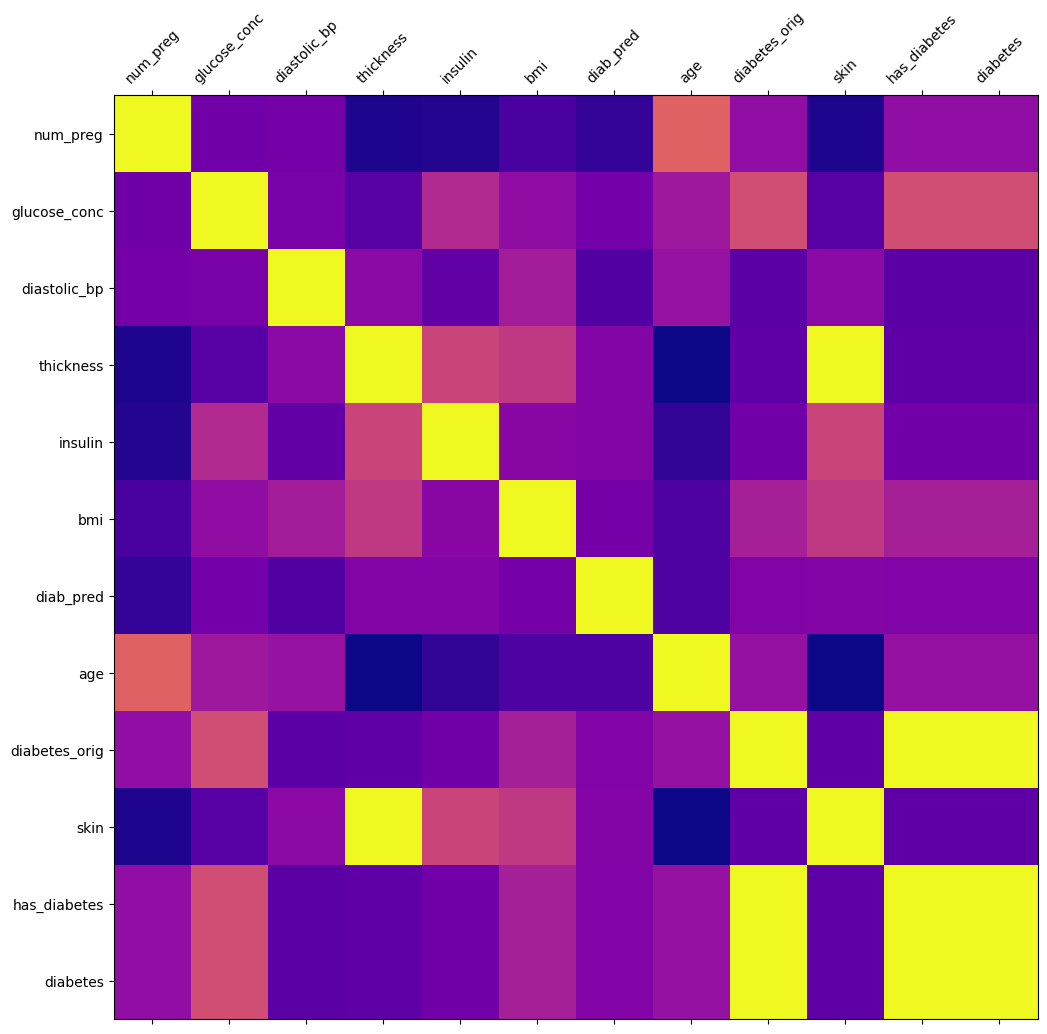

In [9]:
check_corr(12)

In [10]:
df.corr()
# if we are getting diagonal same then it is not corelation id we got beypund it then it is corelation
# it will be difficult to understand

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,diabetes_orig,skin,has_diabetes,diabetes
num_preg,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898,-0.081672,0.221898,0.221898
glucose_conc,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581,0.057328,0.466581,0.466581
diastolic_bp,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068,0.207371,0.065068,0.065068
thickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752,1.000000,0.074752,0.074752
insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548,0.436783,0.130548,0.130548
bmi,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695,0.392573,0.292695,0.292695
diab_pred,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844,0.183928,0.173844,0.173844
age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356,-0.113970,0.238356,0.238356
diabetes_orig,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000,0.074752,1.000000,1.000000
skin,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752,1.000000,0.074752,0.074752


In [11]:
# 1. thickness and skin are colrelated to eachother
# 2. diabetes_orig and has_diabestes  are corelated to each other
# 3. diabetes_orig and diabetes are corelated to each other 
# 4. has_diabetes and diabetes are corelated to each other

# c.drop the corelated columns

In [12]:
df.drop('thickness',axis=1,inplace=True)
df.drop('diabetes_orig',axis=1,inplace=True) # we cant drop result col as diabetes is result we ll not drop it
df.drop('has_diabetes',axis=1,inplace=True)

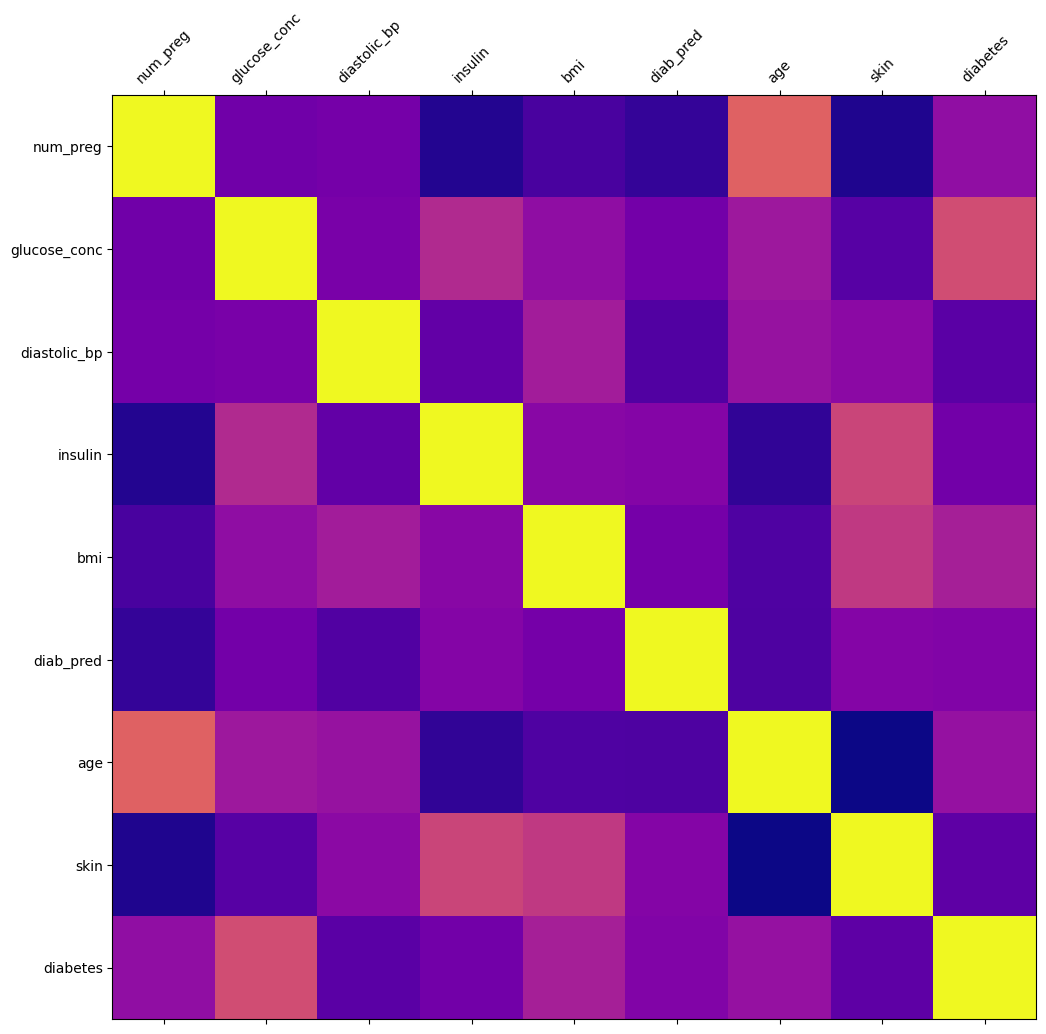

In [13]:
check_corr(12)

In [14]:
#if any two columns are showing same data then we need to idenetify

# d . Convert string data to integer type

In [15]:
df['diabetes'].unique()

array([ True, False])

In [16]:
df['diabetes']=df['diabetes'].map({True:1,False:0})
df.head()

,num_preg,glucose_conc,diastolic_bp,insulin,bmi,diab_pred,age,skin,diabetes
0,6,148,72,0,33.6,0.627,50,1.3790,1
1,1,85,66,0,26.6,0.351,31,1.1426,0
2,8,183,64,0,23.3,0.672,32,0.0000,1
3,1,89,66,94,28.1,0.167,21,0.9062,0
4,0,137,40,168,43.1,2.288,33,1.3790,1


# e .Check the proportion  of data

This means:
There are 268 rows in your dataset where diabetes = 1 (patients with diabetes).
There are 500 rows where diabetes = 0 (patients without diabetes).
So essentially, you are counting the distribution of diabetes cases in your dataset.

In [17]:
num_true=len(df.loc[df['diabetes']==1]) # loc :u can pass col names
num_false=len(df.loc[df['diabetes']==0])
print(f"Num of true data is {num_true}")
print(f"Num of false data is {num_false}")

Num of true data is 268
Num of false data is 500


In [18]:
true_per=(num_true/(num_true+num_false))*100
false_per=(num_false/(num_true+num_false))*100
print(f"true value percentage is {true_per}")
print(f"false value percentage is {false_per}")

true value percentage is 34.89583333333333
false value percentage is 65.10416666666666


This means:
About 34.9% of the dataset are diabetic cases (diabetes = 1).
About 65.1% are non-diabetic cases (diabetes = 0).
So essentially, you are finding the class distribution in percentage form. 
This is very useful in machine learning because it tells you whether your dataset is balanced or imbalanced. 
In your case, the dataset is imbalanced (more non-diabetic than diabetic cases).

Cleaning the data 
a. finding null values 
if present we can use drop na fillna
b. corelation 
c. drop the corelated col
d. convert string data to int type to make model understand properly
e. finding the proportion of data

# step3: Train test split

In [19]:
df.columns

Index(['num_preg', 'glucose_conc', 'diastolic_bp', 'insulin', 'bmi',
       'diab_pred', 'age', 'skin', 'diabetes'],
      dtype='str')

## input_columns:
This list contains the names of the independent variables (features) in your dataset. These are the patient health metrics that will be used by your machine learning model to learn patterns:

num_preg → number of pregnancies

glucose_conc → glucose concentration

diastolic_bp → diastolic blood pressure

insulin → insulin level

bmi → body mass index

diab_pred → diabetes pedigree function (genetic influence score)

age → age of the patient

skin → skin thickness

output_columns:
This list contains the dependent variable (target) you want to predict:

diabetes → whether the patient has diabetes (1) or not (0).

In [20]:
input_columns=['num_preg', 'glucose_conc', 'diastolic_bp', 'insulin', 'bmi','diab_pred', 'age', 'skin']
output_columns=['diabetes']

## You are separating features from the target. This is a standard step in supervised machine learning:

Features (X) → the input data used to train the model.

Target (y) → the output label the model tries to predict

In [21]:
x= df[input_columns].values
y= df[output_columns].values

## After running this, you’ll have the latest version of scikit-learn available in your environment, 
so you can use things like StandardScaler, train_test_split, LogisticRegression, RandomForestClassifier, etc.

## pip install -U scikit-learn

In [22]:
pip install -U scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## In supervised machine learning, we separate our dataset into two parts:

X represents the input features — the independent variables that describe each sample. For example, in the diabetes dataset, X would include columns like glucose concentration, BMI, age, etc.

y represents the output labels — the dependent variable we want to predict. In this case, it’s the diabetes column (1 for diabetic, 0 for non-diabetic).

We then use train_test_split to divide X and y into training and testing sets.

X_train, y_train are used to train the model — the model learns the relationship between features and labels.

X_test, y_test are kept aside to evaluate how well the model generalizes to unseen data.

This separation ensures that the model isn’t just memorizing the training data but can actually make accurate predictions on new inputs.”

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [25]:
#def m1(x,y):
##    return x+y,x-y
#sub1,sum1=m1(10,20)
#print(sub1)
#print(sum1)

In [26]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(537, 8)
(231, 8)
(537, 1)
(231, 1)


## In **Machine Learning**, sampling techniques are mainly used to manage large datasets and deal with imbalanced data. Here’s the short version:

- **Random Sampling** → Pick data points randomly.  
- **Stratified Sampling** → Keep class proportions intact.  
- **Oversampling (e.g., SMOTE)** → Add more minority class samples.  
- **Undersampling** → Reduce majority class samples.  
- **Mini-Batch Sampling** → Train in small batches for efficiency.  
- **Importance Sampling** → Focus on more “informative” data points.  

👉 In practice:  
- For **balanced datasets** → Random or stratified sampling.  
- For **imbalanced datasets** → Oversampling, undersampling, or hybrid methods.  
- For **deep learning** → Mini-batch sampling during training.  

Would you like me to show you a **tiny Python snippet** demonstrating stratified sampling or SMOTE so you can see it in action?


# check the training and testing percentage after train test split

In [27]:
print('{0:0.2f}% in training set'.format((len(x_train)/len(df.index))*100))
print('{0:0.2f}% in training set'.format((len(x_test)/len(df.index))*100))

69.92% in training set
30.08% in training set


In [28]:
print('training true:{0} ({1:0.2f}%)'.format(len(y_train[y_train[:]==1]),
                                             ((len(y_train[y_train[:]==1])/len(y_train))*100)))

print('training false:{0} ({1:0.2f}%)'.format(len(y_train[y_train[:]==0]),
                                             ((len(y_train[y_train[:]==0])/len(y_train))*100)))

training true:188 (35.01%)
training false:349 (64.99%)


In [29]:
print('training true:{0} ({1:0.2f}%)'.format(len(y_test[y_test[:]==1]),
                                             ((len(y_test[y_test[:]==1])/len(y_test))*100)))

print('training false:{0} ({1:0.2f}%)'.format(len(y_test[y_test[:]==0]),
                                             ((len(y_test[y_test[:]==0])/len(y_test))*100)))

training true:80 (34.63%)
training false:151 (65.37%)


# step5 :post split prepartion

In [30]:
df.columns

Index(['num_preg', 'glucose_conc', 'diastolic_bp', 'insulin', 'bmi',
       'diab_pred', 'age', 'skin', 'diabetes'],
      dtype='str')

In [31]:
total_num_preg= len(df.loc[df['num_preg']==0])
print(f"total num of rows missin in num_preg column is {total_num_preg}")

total_glucose_conc= len(df.loc[df['glucose_conc']==0])
print(f"total num of rows missin in gloucose column is {total_glucose_conc}")


total_diastolic_bp= len(df.loc[df['diastolic_bp']==0])
print(f"total num of rows missin in diastolic column is {total_diastolic_bp}")


total_insulin= len(df.loc[df['insulin']==0])
print(f"total num of rows missin in insulin column is {total_insulin}")


total_bmi= len(df.loc[df['bmi']==0])
print(f"total num of rows missin in bmi column is {total_bmi}")


total_diab_pred= len(df.loc[df['diab_pred']==0])
print(f"total num of rows missin in diab_pred column is {total_diab_pred}")


total_age= len(df.loc[df['age']==0])
print(f"total num of rows missin in age column is {total_age}")


total_skin= len(df.loc[df['skin']==0])
print(f"total num of rows missin in skin column is {total_skin}")


total_diabetes= len(df.loc[df['diabetes']==0])
print(f"total num of rows missin in diabetes column is {total_diabetes}")

total num of rows missin in num_preg column is 111
total num of rows missin in gloucose column is 5
total num of rows missin in diastolic column is 35
total num of rows missin in insulin column is 374
total num of rows missin in bmi column is 11
total num of rows missin in diab_pred column is 0
total num of rows missin in age column is 0
total num of rows missin in skin column is 227
total num of rows missin in diabetes column is 500


## To Handle missing values 

In [32]:
from sklearn.impute import SimpleImputer

In [33]:
x_train[:5]

array([[1.0000e+00, 9.5000e+01, 6.0000e+01, 5.8000e+01, 2.3900e+01,
        2.6000e-01, 2.2000e+01, 7.0920e-01],
       [5.0000e+00, 1.0500e+02, 7.2000e+01, 3.2500e+02, 3.6900e+01,
        1.5900e-01, 2.8000e+01, 1.1426e+00],
       [0.0000e+00, 1.3500e+02, 6.8000e+01, 2.5000e+02, 4.2300e+01,
        3.6500e-01, 2.4000e+01, 1.6548e+00],
       [4.0000e+00, 1.3100e+02, 6.8000e+01, 1.6600e+02, 3.3100e+01,
        1.6000e-01, 2.8000e+01, 8.2740e-01],
       [1.0000e+00, 1.0300e+02, 3.0000e+01, 8.3000e+01, 4.3300e+01,
        1.8300e-01, 3.3000e+01, 1.4972e+00]])

In [34]:
fill_zeros = SimpleImputer(missing_values=0, strategy='mean')
x_train = fill_zeros.fit_transform(x_train)
x_test = fill_zeros.fit_transform(x_test)

In [35]:
x_train[:5]

array([[1.00000000e+00, 9.50000000e+01, 6.00000000e+01, 5.80000000e+01,
        2.39000000e+01, 2.60000000e-01, 2.20000000e+01, 7.09200000e-01],
       [5.00000000e+00, 1.05000000e+02, 7.20000000e+01, 3.25000000e+02,
        3.69000000e+01, 1.59000000e-01, 2.80000000e+01, 1.14260000e+00],
       [4.34056399e+00, 1.35000000e+02, 6.80000000e+01, 2.50000000e+02,
        4.23000000e+01, 3.65000000e-01, 2.40000000e+01, 1.65480000e+00],
       [4.00000000e+00, 1.31000000e+02, 6.80000000e+01, 1.66000000e+02,
        3.31000000e+01, 1.60000000e-01, 2.80000000e+01, 8.27400000e-01],
       [1.00000000e+00, 1.03000000e+02, 3.00000000e+01, 8.30000000e+01,
        4.33000000e+01, 1.83000000e-01, 3.30000000e+01, 1.49720000e+00]])

## To train the model
## standardize the data

In [36]:
from sklearn.preprocessing import StandardScaler

# Create the scaler object
scaler = StandardScaler()

# Fit on training data and transform
x_train = scaler.fit_transform(x_train)

# Use the same scaler to transform test data
x_test = scaler.transform(x_test)


## Train the model using Naive bayes

In [37]:
y_train=y_train.astype(int).ravel()
y_test=y_test.astype(int).ravel()
print(y_train.shape)
print(y_test.shape)

(537,)
(231,)


In [38]:
from sklearn.naive_bayes import GaussianNB
nb_model=GaussianNB()
nb_model.fit(x_train,y_train.ravel())

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [39]:
from sklearn  import metrics
nb_predict_model=nb_model.predict(x_train)
print(f"predicted accuracy for training data {metrics.accuracy_score(y_train,nb_predict_model)}")

predicted accuracy for training data 0.7541899441340782


In [40]:
nb_predict_test=nb_model.predict(x_test)
print(f"predicted accuracy for testing data {metrics.accuracy_score(y_test,nb_predict_test)}")

predicted accuracy for testing data 0.7359307359307359


## step6 : Test the accuracey using confusion matrix

In [41]:
print(f"{metrics.confusion_matrix(y_test,nb_predict_test)}")

[[118  33]
 [ 28  52]]


# (tn,fp,fn,tp)
## Accuracy = ((TP+TN)/(TP+FP+FN+TN))
##          =(118+52)/(118+33+28+52)
##          =0.7359

In [42]:
## train_test_split() return tuple values 
# True Positive : (original is tru and predicted also true)
# True negative : original is false and predicted also false

## test the accuracy using classification report
# test the accuracy using classification report

In [43]:
print(f"{metrics.classification_report(y_test,nb_predict_test)}")

              precision    recall  f1-score   support

           0       0.81      0.78      0.79       151
           1       0.61      0.65      0.63        80

    accuracy                           0.74       231
   macro avg       0.71      0.72      0.71       231
weighted avg       0.74      0.74      0.74       231



# Train the model using random Forest

In [44]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [45]:
from sklearn  import metrics
rf_predict_model=rf_model.predict(x_train)
print(f"predicted accuracy for training data {metrics.accuracy_score(y_train,rf_predict_model)}")

predicted accuracy for training data 1.0


In [46]:
rf_predict_test=rf_model.predict(x_test)
print(f"predicted accuracy for testing data {metrics.accuracy_score(y_test,rf_predict_test)}")

predicted accuracy for testing data 0.7532467532467533


In [47]:
print(f"{metrics.confusion_matrix(y_test,rf_predict_test)}")

[[120  31]
 [ 26  54]]


In [48]:
print(f"{metrics.classification_report(y_test,rf_predict_test)}")

              precision    recall  f1-score   support

           0       0.82      0.79      0.81       151
           1       0.64      0.68      0.65        80

    accuracy                           0.75       231
   macro avg       0.73      0.73      0.73       231
weighted avg       0.76      0.75      0.75       231



# Train the model using KNN

In [49]:
from sklearn.neighbors import KNeighborsClassifier
k_neighbor=KNeighborsClassifier()
k_neighbor.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [50]:
from sklearn  import metrics
k_predict_model=k_neighbor.predict(x_train)
print(f"predicted accuracy for training data {metrics.accuracy_score(y_train,k_predict_model)}")

predicted accuracy for training data 0.8379888268156425


In [51]:
k_predict_test=k_neighbor.predict(x_test)
print(f"predicted accuracy for testing data {metrics.accuracy_score(y_test,k_predict_test)}")

predicted accuracy for testing data 0.7012987012987013


In [52]:
print(f"{metrics.confusion_matrix(y_test,k_predict_test)}")

[[113  38]
 [ 31  49]]


In [53]:
print(f"{metrics.classification_report(y_test,k_predict_test)}")

              precision    recall  f1-score   support

           0       0.78      0.75      0.77       151
           1       0.56      0.61      0.59        80

    accuracy                           0.70       231
   macro avg       0.67      0.68      0.68       231
weighted avg       0.71      0.70      0.70       231



In [54]:
## conclusion : we had provided training using naive byes ,random forest , KNN
## we got random forest is giving high accuracy compare to other
## so i will prefer random forest model from my project

In [55]:
input_data=[6,148,72,0,33.6,0.627,50,1.3790]
#input_data=[1,85,66,0,26.6,0.351,31,1.1426]
input_array=np.array(input_data).reshape(1,-1)
print(input_array)
input_array=fill_zeros.transform(input_array)
input_array=scaler.transform(input_array)
print(input_array)               
prediction=rf_model.predict(input_array)
print("Prediction:","Diabetic" if prediction[0]==1 else "Not Diabetic")

[[  6.    148.     72.      0.     33.6     0.627  50.      1.379]]
[[ 0.57468297  0.86398822 -0.01979041  0.00844534  0.19026321  0.45960931
   1.44979298  0.75044047]]
Prediction: Diabetic


In [56]:
import pickle
#save model
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
#save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
#save imputer
with open('imputer.pkl', 'wb') as f:
    pickle.dump(fill_zeros, f)